In [1]:
print("test")

test


In [2]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster       import KMeans, AgglomerativeClustering
from sklearn.metrics       import silhouette_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_squared_error, r2_score

from tensorflow.keras.optimizers import Adam

In [3]:
# Reading Data
df = pd.read_csv("/Users/amin/Desktop/movies_metadata.csv",low_memory=False)
print("Shape Data :",df.shape)

Shape Data : (45466, 24)


2.2.1 Initial Data Inspection

In [4]:
# View Data
pd.set_option('display.max_columns', None)
df.head(5)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
# NAs For Cols
print(df.isna().sum())

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64


In [6]:
# budget Describe
print("Budget")
pd.options.display.float_format = '{:,.0f}'.format
ErrorBudget = df.loc[pd.to_numeric(df["budget"], errors="coerce").isna(),"budget"].index
print("-" * 50)
print("Errors =" , ErrorBudget)
print("-" * 50)
print("Describe For Budget:")
print(df["budget"].drop(ErrorBudget).astype("float64").describe().round(2))
print("=" * 50)

Budget
--------------------------------------------------
Errors = Index([19730, 29503, 35587], dtype='int64')
--------------------------------------------------
Describe For Budget:
count        45,463
mean      4,224,579
std      17,424,133
min               0
25%               0
50%               0
75%               0
max     380,000,000
Name: budget, dtype: float64


In [7]:
# popularity Describe
print("Popularity")
pd.options.display.float_format = '{:,.2f}'.format
ErrorPopularity = df.loc[pd.to_numeric(df["popularity"], errors="coerce").isna(),"popularity"].index
print("-" * 50)
print("Errors =" , ErrorPopularity)
print("-" * 50)
print("Describe For Popularity:")
print(df["popularity"].drop(ErrorPopularity).astype("float64").describe().round(2))
print("=" * 50)

Popularity
--------------------------------------------------
Errors = Index([19729, 19730, 29502, 29503, 35586, 35587], dtype='int64')
--------------------------------------------------
Describe For Popularity:
count   45,460.00
mean         2.92
std          6.01
min          0.00
25%          0.39
50%          1.13
75%          3.68
max        547.49
Name: popularity, dtype: float64


In [8]:
# revenue Describe
print("Revenue")
pd.options.display.float_format = '{:,.0f}'.format
ErrorRevenue = df.loc[pd.to_numeric(df["revenue"], errors="coerce").isna(),"revenue"].index
print("-" * 50)
print("Errors =" , ErrorRevenue)
print("-" * 50)
print("Describe For Revenue:")
print(df["revenue"].drop(ErrorRevenue).astype("float64").describe().round(2))
print("=" * 50)

Revenue
--------------------------------------------------
Errors = Index([19729, 19730, 29502, 29503, 35586, 35587], dtype='int64')
--------------------------------------------------
Describe For Revenue:
count          45,460
mean       11,209,349
std        64,332,247
min                 0
25%                 0
50%                 0
75%                 0
max     2,787,965,087
Name: revenue, dtype: float64


In [9]:
# runtime Describe
print("Runtime")
pd.options.display.float_format = '{:,.0f}'.format
ErrorRuntime = df.loc[pd.to_numeric(df["runtime"], errors="coerce").isna(),"runtime"].index
print("-" * 50)
print("Errors =" , ErrorRuntime)
print("-" * 50)
print("Describe For Runtime:")
print(df["runtime"].drop(ErrorRuntime).astype("float64").describe().round(2))
print("=" * 50)

Runtime
--------------------------------------------------
Errors = Index([  634,   635,   644,   802,   863,  2140, 13562, 13576, 13660, 13757,
       ...
       44988, 45015, 45054, 45062, 45231, 45246, 45310, 45313, 45377, 45410],
      dtype='int64', length=263)
--------------------------------------------------
Describe For Runtime:
count   45,203
mean        94
std         38
min          0
25%         85
50%         95
75%        107
max      1,256
Name: runtime, dtype: float64


In [10]:
# vote_average Describe
print("Vote_Average")
pd.options.display.float_format = '{:,.2f}'.format
ErrorVote_Average = df.loc[pd.to_numeric(df["vote_average"], errors="coerce").isna(),"vote_average"].index
print("-" * 50)
print("Errors =" , ErrorVote_Average)
print("-" * 50)
print("Describe For Vote_Average:")
print(df["vote_average"].drop(ErrorVote_Average).astype("float64").describe().round(2))
print("=" * 50)

Vote_Average
--------------------------------------------------
Errors = Index([19729, 19730, 29502, 29503, 35586, 35587], dtype='int64')
--------------------------------------------------
Describe For Vote_Average:
count   45,460.00
mean         5.62
std          1.92
min          0.00
25%          5.00
50%          6.00
75%          6.80
max         10.00
Name: vote_average, dtype: float64


In [11]:
# vote_count Describe
print("Vote_Count")
pd.options.display.float_format = '{:,.0f}'.format
ErrorVote_Count = df.loc[pd.to_numeric(df["vote_count"], errors="coerce").isna(),"vote_count"].index
print("-" * 50)
print("Errors =" , ErrorVote_Count)
print("-" * 50)
print("Describe For Vote_Count:")
print(df["vote_count"].drop(ErrorVote_Count).astype("float64").describe().round(2))
print("=" * 50)

Vote_Count
--------------------------------------------------
Errors = Index([19729, 19730, 29502, 29503, 35586, 35587], dtype='int64')
--------------------------------------------------
Describe For Vote_Count:
count   45,460
mean       110
std        491
min          0
25%          3
50%         10
75%         34
max     14,075
Name: vote_count, dtype: float64


2.2.2 Data Cleaning

In [12]:
# Drop Column
dfDrop = df.drop(["id", "imdb_id", "overview", "poster_path"], axis = 1)

In [13]:
# =======================================
# Having Or Not For belongs_to_collection
# =======================================

dfDrop["belongs_to_collection"] = (dfDrop["belongs_to_collection"].notna().astype("int8"))
# ==========================
# Having Or Not For homepage
# ==========================

dfDrop["homepage"] = (dfDrop["homepage"].notna().astype("int8"))

# =========================
# Having Or Not For tagline
# =========================

dfDrop["tagline"] = (dfDrop["tagline"].notna().astype("int8"))

In [14]:
# Drop Rows With Na
print("Total Recors    =" ,dfDrop.shape[0])
print("Total NAs       =" ,dfDrop.isna().sum().sum())
print("Rows With Nas   =" ,dfDrop.isna().any(axis = 1).sum())
print("Column With Nas =" ,dfDrop.isna().any(axis = 0).sum())
print("=" * 50)

print("Percent Of Records With Nas =" ,np.round((423/45466)*100,2))

dfDropNa = dfDrop.dropna().copy()

Total Recors    = 45466
Total NAs       = 495
Rows With Nas   = 423
Column With Nas = 13
Percent Of Records With Nas = 0.93


In [15]:
# ===============
# List For genres
# ===============

# Str To List
dfDropNa["genres"] = dfDropNa["genres"].apply(ast.literal_eval)

# Extract
dfDropNa["genres"] = dfDropNa["genres"].apply(
    lambda x: [i["name"] for i in x])

# Example
print(dfDropNa["genres"][0])

# =============================
# List For production_companies
# =============================

# Str To List
dfDropNa["production_companies"] = dfDropNa["production_companies"].apply(ast.literal_eval)

# Extract
dfDropNa["production_companies"] = dfDropNa["production_companies"].apply(
    lambda x: [i["name"] for i in x])

# Example
print(dfDropNa["production_companies"][0])

# =============================
# List For production_countries
# =============================

# Str To List
dfDropNa["production_countries"] = dfDropNa["production_countries"].apply(ast.literal_eval)

# Extract
dfDropNa["production_countries"] = dfDropNa["production_countries"].apply(
    lambda x: [i["name"] for i in x])

# Example
print(dfDropNa["production_countries"][0])

# =============================
# List For spoken_languages
# =============================

# Str To List
dfDropNa["spoken_languages"] = dfDropNa["spoken_languages"].apply(ast.literal_eval)

# Extract
dfDropNa["spoken_languages"] = dfDropNa["spoken_languages"].apply(
    lambda x: [i["name"] for i in x])

# Example
print(dfDropNa["spoken_languages"][0])

['Animation', 'Comedy', 'Family']
['Pixar Animation Studios']
['United States of America']
['English']


In [16]:
# MultiLabel OneHotEncoder

from sklearn.preprocessing import MultiLabelBinarizer
import ast
import pandas as pd

#cols = ["genres", "production_companies", "production_countries, spoken_languages"]

cols = ["genres"]

for col in cols:

    # Convert string to list only if the value is a string
    dfDropNa[col] = dfDropNa[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    # Extract the "name" field from dictionaries
    dfDropNa[col] = dfDropNa[col].apply(
        lambda x: [i["name"] if isinstance(i, dict) else i for i in x]
    )

    # Apply MultiLabelBinarizer
    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(dfDropNa[col]).astype("int8")

    # Create dataframe for encoded columns
    encoded_df = pd.DataFrame(
        encoded,
        columns=[f"{col}_{c}" for c in mlb.classes_],
        index=dfDropNa.index
    )

    # Concatenate encoded columns with original dataframe
    dfDropNa = pd.concat([dfDropNa, encoded_df], axis=1)


# Example values
print(dfDropNa["genres"].iloc[0])

['Animation', 'Comedy', 'Family']


In [17]:
# Chose First Label From MultiLabel 
import ast

#cols = ["genres","production_companies","production_countries","spoken_languages"]

cols = ["production_companies","production_countries","spoken_languages"]

for col in cols:

    # Convert string to list
    dfDropNa[col] = dfDropNa[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    # Extract only first element
    dfDropNa[col] = dfDropNa[col].apply(
        lambda x: x[0]["name"] if len(x) > 0 and isinstance(x[0], dict)
        else (x[0] if len(x) > 0 else None)
    )

# Example
print(dfDropNa["spoken_languages"].iloc[0])
print(dfDropNa["production_companies"].iloc[0])
print(dfDropNa["production_countries"].iloc[0])


English
Pixar Animation Studios
United States of America


In [18]:
# Count Values
print(dfDropNa["production_companies"].value_counts())
print("=" * 50)

print(dfDropNa["production_companies"].value_counts()[0:10])
print("=" * 50)

print(dfDropNa["production_countries"].value_counts())
print("=" * 50)

print(dfDropNa["production_countries"].value_counts()[0:10])
print("=" * 50)

print(dfDropNa["spoken_languages"].value_counts())
print("=" * 50)

print(dfDropNa["spoken_languages"].value_counts()[0:10])
print("=" * 50)

production_companies
Paramount Pictures                        997
Metro-Goldwyn-Mayer (MGM)                 852
Twentieth Century Fox Film Corporation    780
Warner Bros.                              756
Universal Pictures                        754
                                         ... 
Quite Nice Pictures                         1
Apostle Productions                         1
Arrete Ton Cinema                           1
Lüthje & Schneider Filmproduktion           1
Yermoliev                                   1
Name: count, Length: 10574, dtype: int64
production_companies
Paramount Pictures                        997
Metro-Goldwyn-Mayer (MGM)                 852
Twentieth Century Fox Film Corporation    780
Warner Bros.                              756
Universal Pictures                        754
Columbia Pictures                         429
Columbia Pictures Corporation             401
RKO Radio Pictures                        290
United Artists                            2

In [19]:
# Top N = 10

# production_countries
top_countries = dfDropNa["production_countries"].value_counts().nlargest(10).index

dfDropNa["production_countries"] = dfDropNa["production_countries"].apply(
    lambda x: x if x in top_countries else "Other"
)

dfDropNa = pd.get_dummies(dfDropNa, columns=["production_countries"])


# production_companies
top_companies = dfDropNa["production_companies"].value_counts().nlargest(10).index

dfDropNa["production_companies"] = dfDropNa["production_companies"].apply(
    lambda x: x if x in top_companies else "Other"
)

dfDropNa = pd.get_dummies(dfDropNa, columns=["production_companies"])


# spoken_languages
top_languages = dfDropNa["spoken_languages"].value_counts().nlargest(10).index

dfDropNa["spoken_languages"] = dfDropNa["spoken_languages"].apply(
    lambda x: x if x in top_languages else "Other"
)

dfDropNa = pd.get_dummies(dfDropNa, columns=["spoken_languages"])


# Convert boolean columns to int
bool_cols = dfDropNa.select_dtypes(include="bool").columns

dfDropNa[bool_cols] = dfDropNa[bool_cols].astype("int8")

In [20]:
# convert to datetime
dfDropNa["release_date"] = pd.to_datetime(dfDropNa["release_date"], errors="coerce")

# create 3 features
dfDropNa["release_year"] = dfDropNa["release_date"].dt.year.astype("int16")
dfDropNa["release_month"] = dfDropNa["release_date"].dt.month.astype("int8")
dfDropNa["release_day"] = dfDropNa["release_date"].dt.day.astype("int8")

# optional: drop original column
dfDropNa.drop(columns=["release_date"], inplace=True)


In [21]:
# Convert True/False style columns
dfDropNa["adult"] = dfDropNa["adult"].map({
    "False": 0,
    "True": 1,
    False: 0,
    True: 1
}).astype("int8")

dfDropNa["video"] = dfDropNa["video"].map({
    "False": 0,
    "True": 1,
    False: 0,
    True: 1
}).astype("int8")

# Numeric columns
numeric_cols = [
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count"
]

# Convert to numeric
for col in numeric_cols:
    dfDropNa[col] = pd.to_numeric(dfDropNa[col], errors="coerce").astype("float64")


In [22]:
# Drop Col
dfDropNa = dfDropNa.drop(["genres" , "original_language"],axis = 1).copy()

# Status OneHot Released
dfDropNa["status_released"] = (dfDropNa["status"] == "Released").astype("int8")
dfDropNa = dfDropNa.drop(["status"],axis = 1).copy()

In [23]:
dfClean = dfDropNa.copy()
dfClean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45043 entries, 0 to 45465
Data columns (total 70 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   adult                                                        45043 non-null  int8   
 1   belongs_to_collection                                        45043 non-null  int8   
 2   budget                                                       45043 non-null  float64
 3   homepage                                                     45043 non-null  int8   
 4   original_title                                               45043 non-null  object 
 5   popularity                                                   45043 non-null  float64
 6   revenue                                                      45043 non-null  float64
 7   runtime                                                      45043 non-null  floa

In [24]:
dfClean.head(10)

,adult,belongs_to_collection,budget,homepage,original_title,popularity,revenue,runtime,tagline,title,video,vote_average,vote_count,genres_Action,genres_Adventure,genres_Animation,genres_Comedy,genres_Crime,genres_Documentary,genres_Drama,genres_Family,genres_Fantasy,genres_Foreign,genres_History,genres_Horror,genres_Music,genres_Mystery,genres_Romance,genres_Science Fiction,genres_TV Movie,genres_Thriller,genres_War,genres_Western,production_countries_Canada,production_countries_France,production_countries_Germany,production_countries_India,production_countries_Italy,production_countries_Japan,production_countries_Other,production_countries_Russia,production_countries_Spain,production_countries_United Kingdom,production_countries_United States of America,production_companies_Columbia Pictures,production_companies_Columbia Pictures Corporation,production_companies_Metro-Goldwyn-Mayer (MGM),production_companies_Other,production_companies_Paramount Pictures,production_companies_RKO Radio Pictures,production_companies_Twentieth Century Fox Film Corporation,production_companies_United Artists,production_companies_Universal Pictures,production_companies_Walt Disney Pictures,production_companies_Warner Bros.,spoken_languages_Deutsch,spoken_languages_English,spoken_languages_Español,spoken_languages_Français,spoken_languages_Italiano,spoken_languages_Other,spoken_languages_Pусский,spoken_languages_हिन्दी,spoken_languages_日本語,spoken_languages_普通话,spoken_languages_한국어/조선말,release_year,release_month,release_day,status_released
0,0,1,"30,000,000",1,Toy Story,22,"373,554,033",81,0,Toy Story,0,8,"5,415",0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,10,30,1
1,0,0,"65,000,000",0,Jumanji,17,"262,797,249",104,1,Jumanji,0,7,"2,413",0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,12,15,1
2,0,1,0,0,Grumpier Old Men,12,0,101,1,Grumpier Old Men,0,6,92,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1995,12,22,1
3,0,0,"16,000,000",0,Waiting to Exhale,4,"81,452,156",127,1,Waiting to Exhale,0,6,34,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,12,22,1
4,0,1,0,0,Father of the Bride Part II,8,"76,578,911",106,1,Father of the Bride Part II,0,6,173,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,2,10,1
5,0,0,"60,000,000",0,Heat,18,"187,436,818",170,1,Heat,0,8,"1,886",1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,12,15,1
6,0,0,"58,000,000",0,Sabrina,7,0,127,1,Sabrina,0,6,141,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1995,12,15,1
7,0,0,0,0,Tom and Huck,3,0,97,1,Tom and Huck,0,5,45,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1995,12,22,1
8,0,0,"35,000,000",0,Sudden Death,5,"64,350,171",106,1,Sudden Death,0,6,174,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,12,22,1
9,0,1,"58,000,000",1,GoldenEye,15,"352,194,034",130,1,GoldenEye,0,7,"1,194",1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,11,16,1


2.2.3 Visualization

Zero Budget Count =  36170


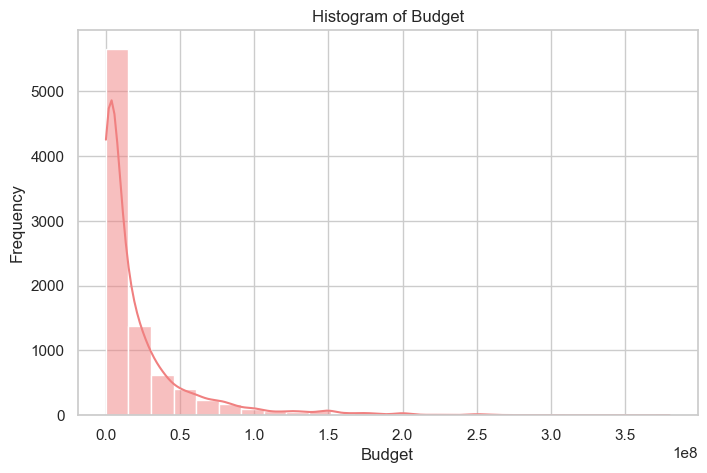

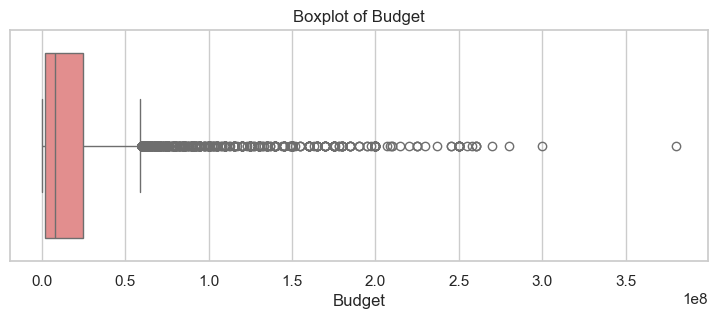

In [25]:
# Budget Visualization

sns.set_theme(style="whitegrid")

print("Zero Budget Count = " , sum(dfClean["budget"] == 0))
 
# nonzeros ==> dfClean.loc[dfClean['budget'] != 0 , 'budget']

# Histogram for Budget
plt.figure(figsize=(8, 5))
sns.histplot(dfClean.loc[dfClean['budget'] != 0 , 'budget'], kde=True, bins=25, color='lightcoral')
plt.title('Histogram of Budget')
plt.xlabel('Budget')
plt.ylabel('Frequency')
plt.show()

# Boxplot for Budget
plt.figure(figsize=(9, 3))
sns.boxplot(x= dfClean.loc[dfClean['budget'] != 0 , 'budget'], color='lightcoral')
plt.title('Boxplot of Budget')
plt.xlabel('Budget')
plt.show()


Zero Runtime Count =  1517


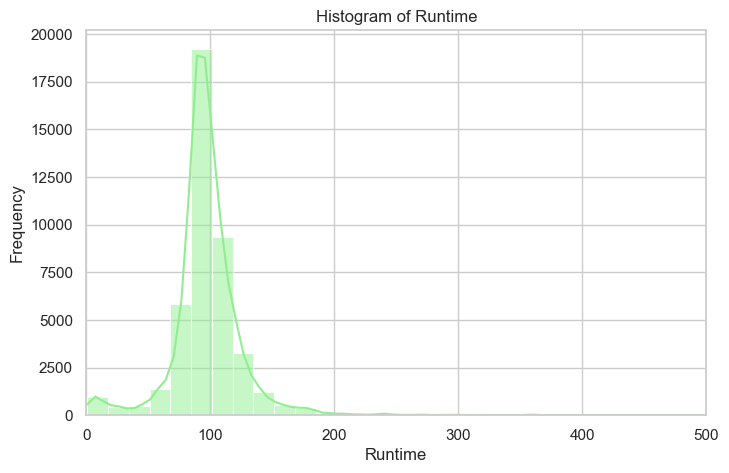

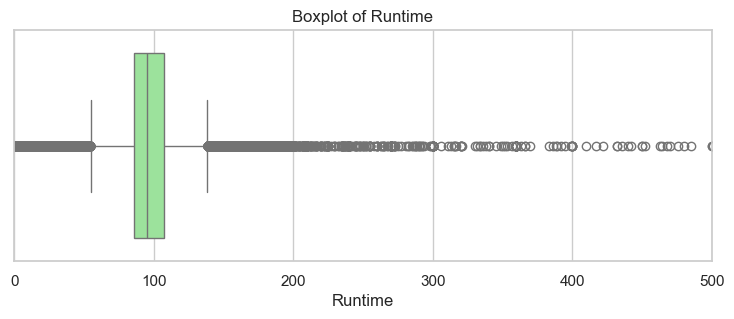

In [26]:
# Runtime Visualization

print("Zero Runtime Count = " , sum(dfClean["runtime"] == 0))
 
# nonzeros ==> dfClean.loc[dfClean['runtime'] != 0 , 'runtime']

# Histogram for Runtime
plt.figure(figsize=(8, 5))
sns.histplot(dfClean.loc[dfClean['runtime'] != 0 , 'runtime'], kde=True, bins=75, color='lightgreen')
plt.title('Histogram of Runtime')
plt.xlabel('Runtime')
plt.ylabel('Frequency')
plt.xlim(0,500)
plt.show()

# Boxplot for Runtime
plt.figure(figsize=(9, 3))
sns.boxplot(x=dfClean.loc[dfClean['runtime'] != 0 , 'runtime'], color='lightgreen')
plt.title('Boxplot of Runtime')
plt.xlabel('Runtime')
plt.xlim(0,500)
plt.show()


Zero Vote Average Count =  2828


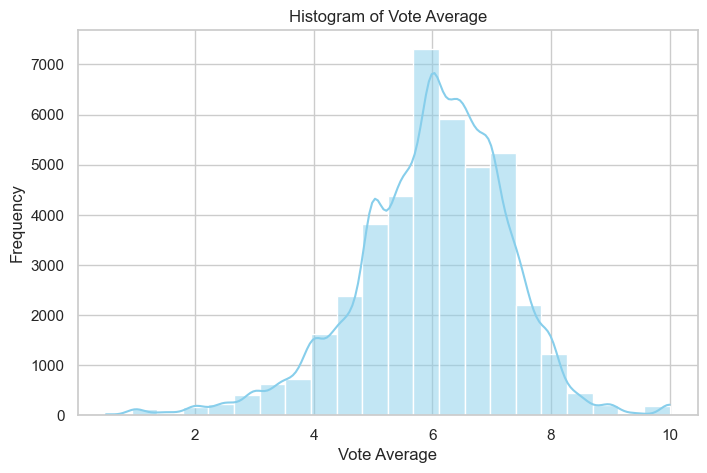

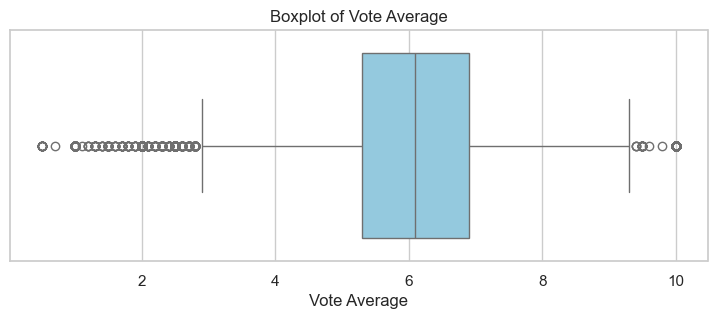

In [27]:
# Vote Average Visualization

print("Zero Vote Average Count = " , sum(dfClean["vote_average"] == 0))
 
# nonzeros ==> dfClean.loc[dfClean['vote_average'] != 0 , 'vote_average']

# Histogram for Vote Average
plt.figure(figsize=(8, 5))
sns.histplot(dfClean.loc[dfClean['vote_average'] != 0 , 'vote_average'], kde=True, bins=22, color='skyblue')
plt.title('Histogram of Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.show()

# Boxplot for Vote Average
plt.figure(figsize=(9, 3))
sns.boxplot(x=dfClean.loc[dfClean['vote_average'] != 0 , 'vote_average'], color='skyblue')
plt.title('Boxplot of Vote Average')
plt.xlabel('Vote Average')
plt.show()


popularity Smaller than 10 = 42026


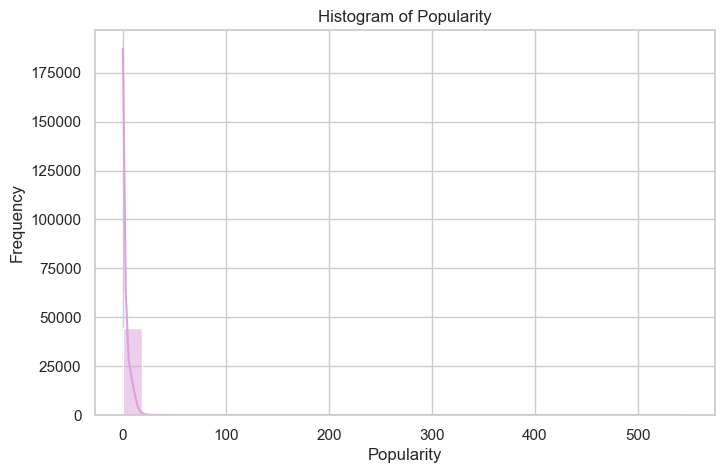

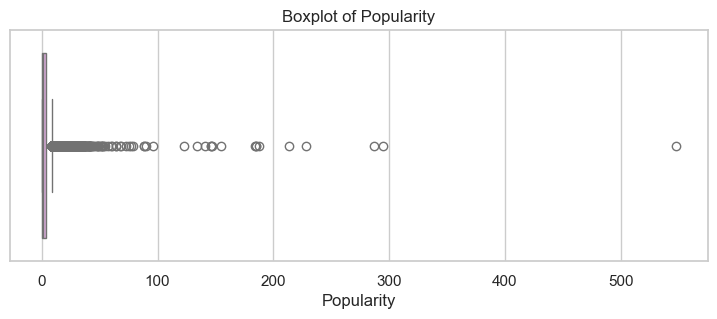

In [28]:
#Popularity Visualization

print("popularity Smaller than 10 =" , sum(dfClean["popularity"] < 10))

# Histogram for Popularity
plt.figure(figsize=(8, 5))
sns.histplot(dfClean["popularity"], kde=True, bins=30, color='plum')
plt.title('Histogram of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

# Boxplot for Popularity
plt.figure(figsize=(9, 3))
sns.boxplot(x=dfClean["popularity"], color='plum')
plt.title('Boxplot of Popularity')
plt.xlabel('Popularity')
plt.show()


Zero Revenue Count =  37643


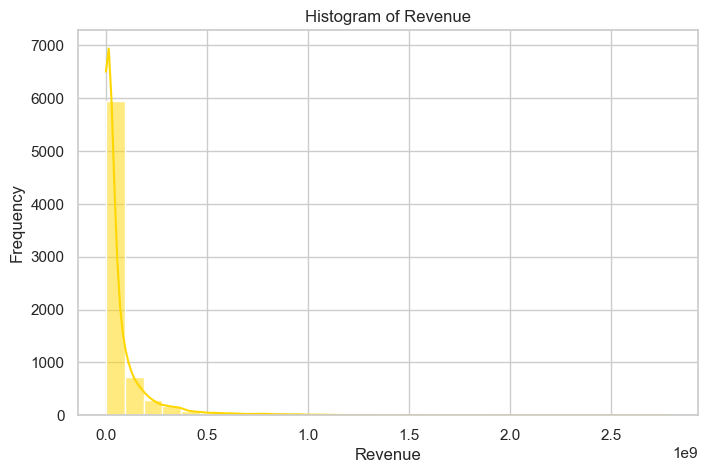

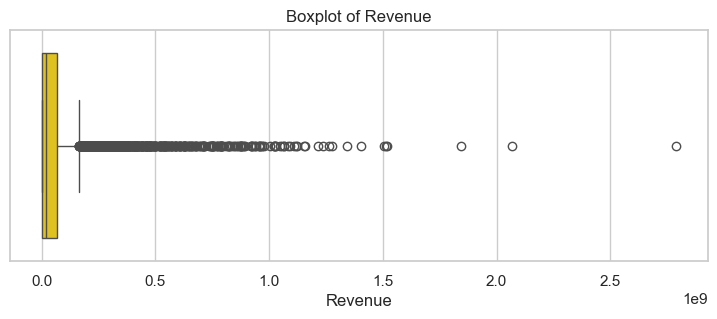

In [29]:
# Revenue Visualization

print("Zero Revenue Count = " , sum(dfClean["revenue"] == 0))
 
# nonzeros ==> dfClean.loc[dfClean['revenue'] != 0 , 'revenue']

# Histogram for Revenue
plt.figure(figsize=(8, 5))
sns.histplot(dfClean.loc[dfClean['revenue'] != 0 , 'revenue'], kde=True, bins=30, color='gold')
plt.title('Histogram of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

# Boxplot for Revenue
plt.figure(figsize=(9, 3))
sns.boxplot(x= dfClean.loc[dfClean['revenue'] != 0 , 'revenue'], color='gold')
plt.title('Boxplot of Revenue')
plt.xlabel('Revenue')
plt.show()


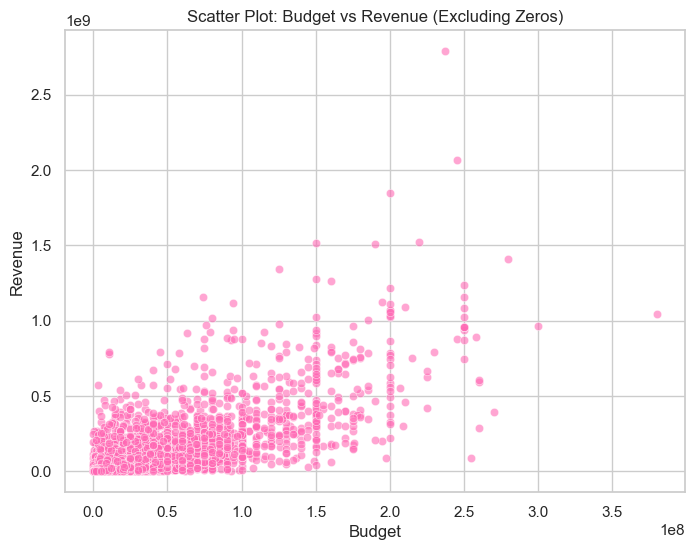

Correlation Coefficient: 0.73


In [30]:
# 1. Scatter plot: budget vs revenue

df_valid = dfClean[(dfClean['budget'] > 0) & (dfClean['revenue'] > 0) & (dfClean['vote_average'] > 0)]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_valid, x='budget', y='revenue', color='hotpink', alpha=0.6)
plt.title('Scatter Plot: Budget vs Revenue (Excluding Zeros)')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

correlation_coef = df_valid['budget'].corr(df_valid['revenue']).round(2)

print(f"Correlation Coefficient: {correlation_coef}")

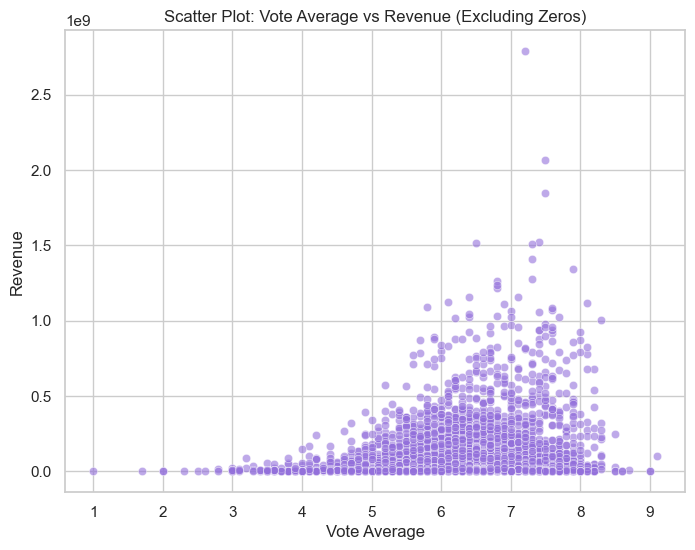

Correlation Coefficient: 0.17


In [31]:
# 2. Scatter plot: vote_average vs revenue

df_valid = dfClean[(dfClean['budget'] > 0) & (dfClean['revenue'] > 0) & (dfClean['vote_average'] > 0)]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_valid, x='vote_average', y='revenue', color='mediumpurple', alpha=0.6)
plt.title('Scatter Plot: Vote Average vs Revenue (Excluding Zeros)')
plt.xlabel('Vote Average')
plt.ylabel('Revenue')
plt.show()

correlation_coef = df_valid['vote_average'].corr(df_valid['revenue']).round(2)

print(f"Correlation Coefficient: {correlation_coef}")

df_valid Shape = (5380, 70)


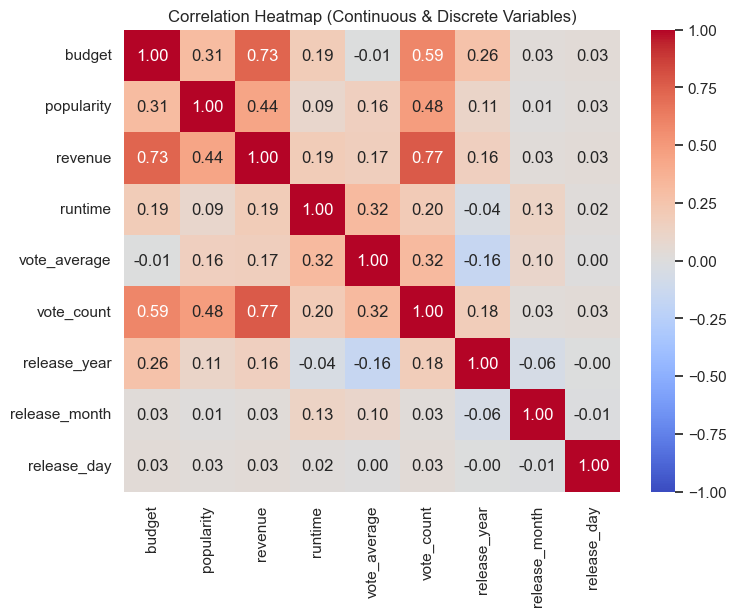

In [32]:
# HeatMap For Nonzero Data
df_valid = dfClean[(dfClean['budget'] > 0) & (dfClean['revenue'] > 0)]

cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count', 'release_year', 'release_month', 'release_day' ]

print("df_valid Shape =" , df_valid.shape)

# Calculate the correlation matrix
corr_matrix = df_valid[cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Continuous & Discrete Variables)')
plt.show()

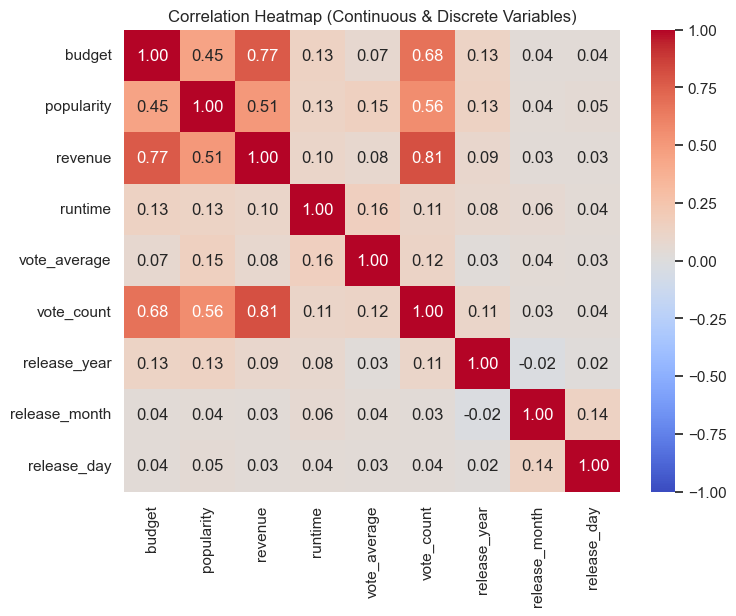

In [33]:
# HeatMap For All Data
cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count', 'release_year', 'release_month', 'release_day' ]

# Calculate the correlation matrix
corr_matrix = dfClean[cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Continuous & Discrete Variables)')
plt.show()

2.3 Clustering Analysis

Data shape for clustering: (5380, 70)
Running K-Means for k=2 to 10...


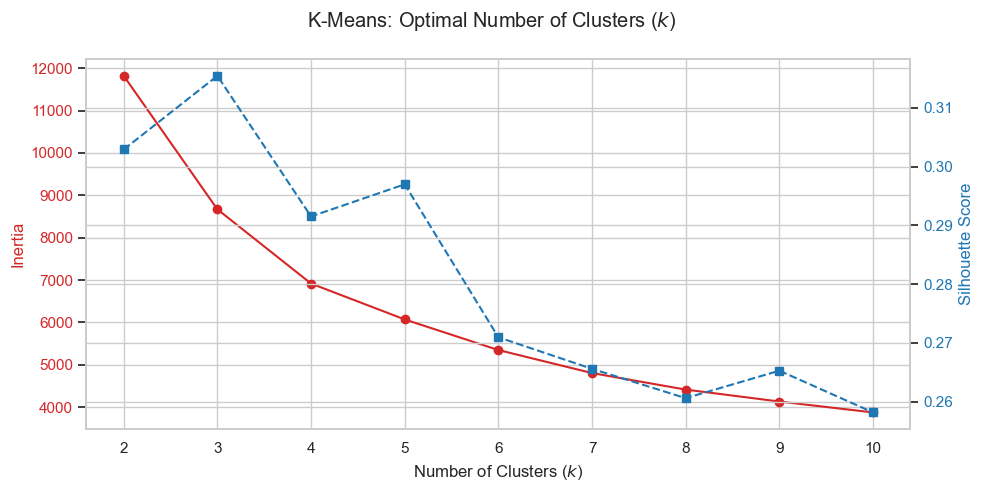

In [34]:
# Define the features to be used for clustering (excluding revenue)
cluster_features = ['budget', 'runtime', 'vote_average']

# To get meaningful clusters, we filter out rows where these features are zero 
# (similar to what was done in the EDA section for valid scatter plots)
df_cluster = dfClean[(dfClean['budget']  > 0)  &
                     (dfClean['revenue'] > 0)].copy()


print(f"Data shape for clustering: {df_cluster.shape}")


# ==========================================
# 2.3.1 Feature Normalization
# ==========================================
# Standardizing the features to have a mean of 0 and a variance of 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

# ==========================================
# 2.3.2 & 2.3.3 K-Means Clustering & Optimal Number of Clusters
# ==========================================
K_range = range(2, 11)
kmeans_inertias = []
kmeans_silhouettes = []

print("Running K-Means for k=2 to 10...")
for k in K_range:
    # Initialize and fit K-Means model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate Inertia (within-cluster sum of squares)
    kmeans_inertias.append(kmeans.inertia_)
    
    # Calculate Silhouette Score
    sil_score = silhouette_score(X_scaled, kmeans_labels)
    kmeans_silhouettes.append(sil_score)

# Plotting K-Means Metrics (Elbow Method & Silhouette)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia
color = 'tab:red'
ax1.set_xlabel('Number of Clusters ($k$)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, kmeans_inertias, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  

# Plot Silhouette Score
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, kmeans_silhouettes, marker='s', linestyle='dashed', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('K-Means: Optimal Number of Clusters ($k$)')
fig.tight_layout()
plt.show()

Running Hierarchical Clustering for k=2 to 10...


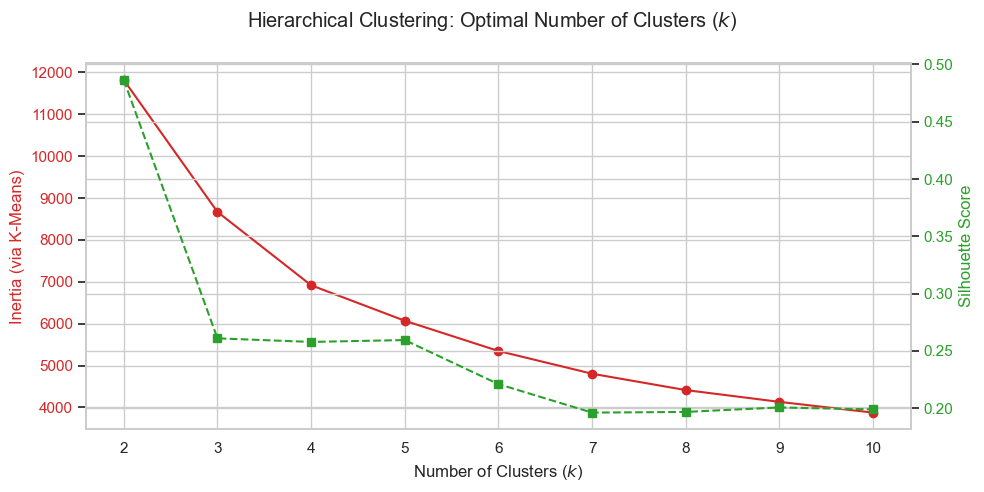

In [35]:
# ==========================================
# 2.3.4 Hierarchical Clustering
# ==========================================
hc_inertias = []
hc_silhouettes = []

print("Running Hierarchical Clustering for k=2 to 10...")
for k in K_range:
    # 1. Run Agglomerative Clustering
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    hc_labels = hc.fit_predict(X_scaled)
    
    # 2. Fit a separate K-Means model solely to compute inertia (as requested in the instructions)
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    hc_inertias.append(kmeans_temp.inertia_)
    
    # 3. Compute Silhouette score directly from Hierarchical results
    sil_score_hc = silhouette_score(X_scaled, hc_labels, metric='euclidean')
    hc_silhouettes.append(sil_score_hc)

# Plotting Hierarchical Metrics
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia (from K-Means proxy)
color = 'tab:red'
ax1.set_xlabel('Number of Clusters ($k$)')
ax1.set_ylabel('Inertia (via K-Means)', color=color)
ax1.plot(K_range, hc_inertias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  

# Plot Silhouette Score
color = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, hc_silhouettes, marker='s', linestyle='dashed', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Hierarchical Clustering: Optimal Number of Clusters ($k$)')
fig.tight_layout()
plt.show()

In [36]:
# ==========================================
# 2.3.5 Assignment
# ==========================================

# K = 5

optimal_k = 5 
print(f"Assigning cluster labels using K-Means with k={optimal_k}")

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['cluster_label'] = final_kmeans.fit_predict(X_scaled)

# Show the count of movies in each cluster
print(df_cluster['cluster_label'].value_counts())

# 1. One-Hot Encoding the cluster labels
df_cluster = pd.get_dummies(df_cluster, columns=['cluster_label'], prefix='cluster', dtype=int)

Assigning cluster labels using K-Means with k=5
cluster_label
2    2056
0    1375
4     881
1     779
3     289
Name: count, dtype: int64


In [37]:
df_cluster.head(1)

,adult,belongs_to_collection,budget,homepage,original_title,popularity,revenue,runtime,tagline,title,video,vote_average,vote_count,genres_Action,genres_Adventure,genres_Animation,genres_Comedy,genres_Crime,genres_Documentary,genres_Drama,genres_Family,genres_Fantasy,genres_Foreign,genres_History,genres_Horror,genres_Music,genres_Mystery,genres_Romance,genres_Science Fiction,genres_TV Movie,genres_Thriller,genres_War,genres_Western,production_countries_Canada,production_countries_France,production_countries_Germany,production_countries_India,production_countries_Italy,production_countries_Japan,production_countries_Other,production_countries_Russia,production_countries_Spain,production_countries_United Kingdom,production_countries_United States of America,production_companies_Columbia Pictures,production_companies_Columbia Pictures Corporation,production_companies_Metro-Goldwyn-Mayer (MGM),production_companies_Other,production_companies_Paramount Pictures,production_companies_RKO Radio Pictures,production_companies_Twentieth Century Fox Film Corporation,production_companies_United Artists,production_companies_Universal Pictures,production_companies_Walt Disney Pictures,production_companies_Warner Bros.,spoken_languages_Deutsch,spoken_languages_English,spoken_languages_Español,spoken_languages_Français,spoken_languages_Italiano,spoken_languages_Other,spoken_languages_Pусский,spoken_languages_हिन्दी,spoken_languages_日本語,spoken_languages_普通话,spoken_languages_한국어/조선말,release_year,release_month,release_day,status_released,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,0,1,"30,000,000",1,Toy Story,22,"373,554,033",81,0,Toy Story,0,8,"5,415",0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,10,30,1,0,0,1,0,0


In [38]:
# ==========================================
# 2.4 Neural Network for Revenue Prediction
# ==========================================

# Filter out rows where revenue is 0 (missing/invalid targets)
# Assuming df_cluster is defined earlier in your code

df_cluster = dfClean[(dfClean['budget']  > 0)  &
                     (dfClean['revenue'] > 0)].copy()
df_cluster['cluster_label'] = final_kmeans.fit_predict(X_scaled)
df_cluster = pd.get_dummies(df_cluster, columns=['cluster_label'], prefix='cluster', dtype=int)

df_nn = df_cluster.drop(["original_title" , "title"] , axis = 1).copy()

# Define Features (X) and Target (y)
# Exclude 'revenue' from features
X = df_nn.drop(columns=['revenue'])
y = df_nn['revenue']

# Convert all features to float32 for Neural Network compatibility
X = X.astype('float32')
y = y.astype('float32')

# ==========================================
# 2.4.1 Data Splitting
# ==========================================
# First, split data into 70% Train and 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second, split the Temporary data equally to get 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ==========================================
# 2.4.2 Feature Normalization (X and y)
# ==========================================
# Apply StandardScaler for Features (X). Fit ONLY on the training data.
scaler_nn = StandardScaler()

X_train_scaled = scaler_nn.fit_transform(X_train)
X_val_scaled   = scaler_nn.transform(X_val)
X_test_scaled  = scaler_nn.transform(X_test)

# Apply StandardScaler for Target (y) to improve convergence.
scaler_y = StandardScaler()

# Reshape y to 2D array as expected by StandardScaler
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))


Training set: 3766 samples
Validation set: 807 samples
Test set: 807 samples


In [39]:
df_nn.head(1)

,adult,belongs_to_collection,budget,homepage,popularity,revenue,runtime,tagline,video,vote_average,vote_count,genres_Action,genres_Adventure,genres_Animation,genres_Comedy,genres_Crime,genres_Documentary,genres_Drama,genres_Family,genres_Fantasy,genres_Foreign,genres_History,genres_Horror,genres_Music,genres_Mystery,genres_Romance,genres_Science Fiction,genres_TV Movie,genres_Thriller,genres_War,genres_Western,production_countries_Canada,production_countries_France,production_countries_Germany,production_countries_India,production_countries_Italy,production_countries_Japan,production_countries_Other,production_countries_Russia,production_countries_Spain,production_countries_United Kingdom,production_countries_United States of America,production_companies_Columbia Pictures,production_companies_Columbia Pictures Corporation,production_companies_Metro-Goldwyn-Mayer (MGM),production_companies_Other,production_companies_Paramount Pictures,production_companies_RKO Radio Pictures,production_companies_Twentieth Century Fox Film Corporation,production_companies_United Artists,production_companies_Universal Pictures,production_companies_Walt Disney Pictures,production_companies_Warner Bros.,spoken_languages_Deutsch,spoken_languages_English,spoken_languages_Español,spoken_languages_Français,spoken_languages_Italiano,spoken_languages_Other,spoken_languages_Pусский,spoken_languages_हिन्दी,spoken_languages_日本語,spoken_languages_普通话,spoken_languages_한국어/조선말,release_year,release_month,release_day,status_released,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,0,1,"30,000,000",1,22,"373,554,033",81,0,0,8,"5,415",0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1995,10,30,1,0,0,1,0,0


In [40]:
# ==========================================
# 2.4.3 Neural Network Architecture
# ==========================================
# Build the Sequential model
model = Sequential()

# Input layer & First hidden layer: 64 neurons, ReLU activation
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Second hidden layer: 32 neurons, ReLU activation
model.add(Dense(32, activation='relu'))

# Output layer: 1 neuron, Linear activation (for regression)
model.add(Dense(1, activation='linear'))

# ==========================================
# 2.4.4 Training Configuration
# ==========================================
# Compile the model with Adam optimizer (Increased learning rate) and MSE loss
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse')

# Train the model 
epochs_count = 30
batch_size_count = 32 

print("Training the Neural Network...")
history = model.fit(
    X_train_scaled, y_train_scaled, # Using SCALED y for training
    validation_data=(X_val_scaled, y_val_scaled), # Using SCALED y for validation
    epochs=epochs_count,
    batch_size=batch_size_count,
    verbose=1 # Change to 0 to hide epoch progress
)

Training the Neural Network...
Epoch 1/30


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6075 - val_loss: 1.3204
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - loss: 0.9763 - val_loss: 0.9184
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 0.7062 - val_loss: 0.6951
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.5541 - val_loss: 0.5748
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - loss: 0.4675 - val_loss: 0.5071
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - loss: 0.4116 - val_loss: 0.4667
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 0.3755 - val_loss: 0.4417
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - loss: 0.3497 - val_loss: 0.4235
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.3293 - val_loss: 0.4089
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 0.3132 - val_loss: 0.3975
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 0.3009 - val_loss: 0.3883
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s

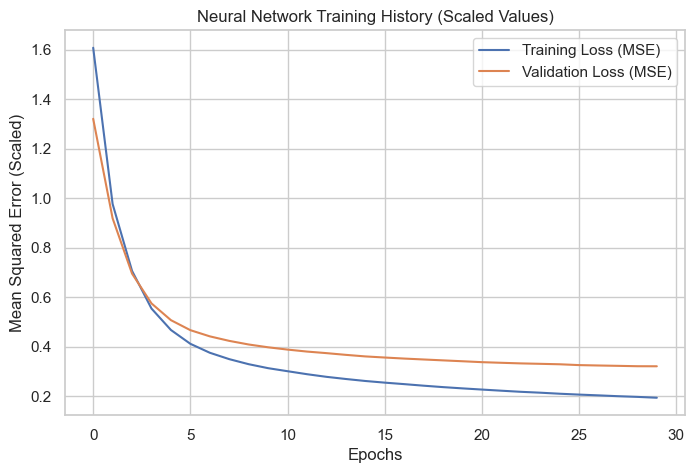

In [41]:
# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Neural Network Training History (Scaled Values)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Scaled)')
plt.legend()
plt.show()


In [42]:
# ==========================================
# 2.4.5 Evaluation
# ==========================================
# Predict on the test set (unseen data) -> Output will be in scaled format
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform predictions to get real revenue values back
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Calculate Evaluation Metrics using the ORIGINAL y_test and REVERTED y_pred
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("Neural Network Evaluation on Test Set (Original Scale):")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Coefficient of Determination (R2 Score): {r2:.4f}")
print("=" * 50)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Neural Network Evaluation on Test Set (Original Scale):
Mean Squared Error (MSE): 5,915,332,828,987,392.00
Coefficient of Determination (R2 Score): 0.7182


For All Data With Zeros

Data shape for clustering: (45043, 70)
Running K-Means for k=2 to 10...
done
done
done
done
done
done
done
done
done


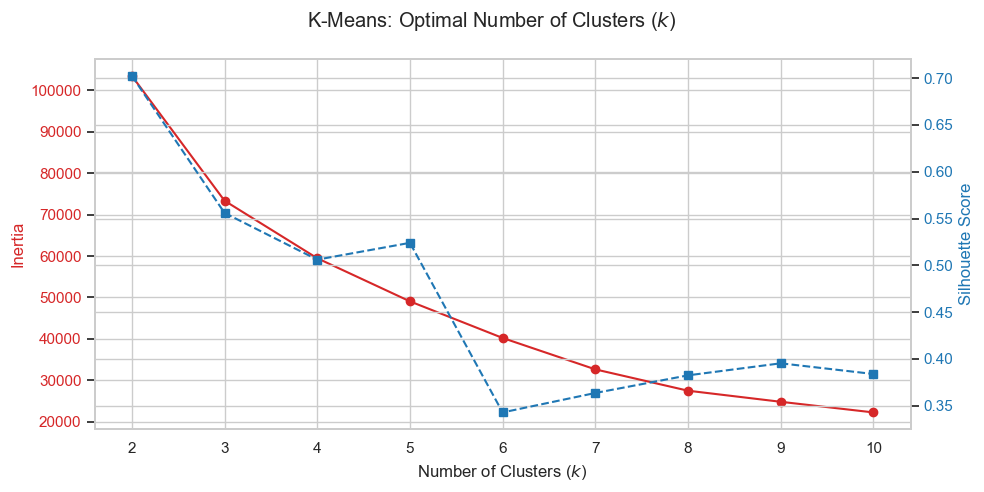

In [42]:
# Define the features to be used for clustering (excluding revenue)
cluster_features = ['budget', 'runtime', 'vote_average']

# To get meaningful clusters, we filter out rows where these features are zero 
# (similar to what was done in the EDA section for valid scatter plots)
df_cluster = dfClean.copy()


print(f"Data shape for clustering: {df_cluster.shape}")


# ==========================================
# 2.3.1 Feature Normalization
# ==========================================
# Standardizing the features to have a mean of 0 and a variance of 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_features])

# ==========================================
# 2.3.2 & 2.3.3 K-Means Clustering & Optimal Number of Clusters
# ==========================================
K_range = range(2, 11)
kmeans_inertias = []
kmeans_silhouettes = []

print("Running K-Means for k=2 to 10...")
for k in K_range:
    # Initialize and fit K-Means model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate Inertia (within-cluster sum of squares)
    kmeans_inertias.append(kmeans.inertia_)
    
    # Calculate Silhouette Score
    sil_score = silhouette_score(X_scaled, kmeans_labels)
    kmeans_silhouettes.append(sil_score)
    print("done")

# Plotting K-Means Metrics (Elbow Method & Silhouette)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia
color = 'tab:red'
ax1.set_xlabel('Number of Clusters ($k$)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, kmeans_inertias, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  

# Plot Silhouette Score
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, kmeans_silhouettes, marker='s', linestyle='dashed', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('K-Means: Optimal Number of Clusters ($k$)')
fig.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 2.3.4 Hierarchical Clustering
# ==========================================
hc_inertias = []
hc_silhouettes = []

print("Running Hierarchical Clustering for k=2 to 10...")
for k in K_range:
    # 1. Run Agglomerative Clustering
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    hc_labels = hc.fit_predict(X_scaled)
    
    # 2. Fit a separate K-Means model solely to compute inertia (as requested in the instructions)
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    hc_inertias.append(kmeans_temp.inertia_)
    
    # 3. Compute Silhouette score directly from Hierarchical results
    sil_score_hc = silhouette_score(X_scaled, hc_labels, metric='euclidean')
    hc_silhouettes.append(sil_score_hc)
    print("done")

# Plotting Hierarchical Metrics
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia (from K-Means proxy)
color = 'tab:red'
ax1.set_xlabel('Number of Clusters ($k$)')
ax1.set_ylabel('Inertia (via K-Means)', color=color)
ax1.plot(K_range, hc_inertias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()  

# Plot Silhouette Score
color = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, hc_silhouettes, marker='s', linestyle='dashed', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Hierarchical Clustering: Optimal Number of Clusters ($k$)')
fig.tight_layout()
plt.show()

Running Hierarchical Clustering for k=2 to 10...


In [43]:
# ==========================================
# 2.3.5 Assignment
# ==========================================

# K = 5

optimal_k = 5 
print(f"Assigning cluster labels using K-Means with k={optimal_k}")

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['cluster_label'] = final_kmeans.fit_predict(X_scaled)

# Show the count of movies in each cluster
print(df_cluster['cluster_label'].value_counts())

# 1. One-Hot Encoding the cluster labels
df_cluster = pd.get_dummies(df_cluster, columns=['cluster_label'], prefix='cluster', dtype=int)

Assigning cluster labels using K-Means with k=5
cluster_label
0    36264
1     4117
3     3278
2     1202
4      182
Name: count, dtype: int64


In [44]:
# ==========================================
# 2.4 Neural Network for Revenue Prediction
# ==========================================

# Filter out rows where revenue is 0 (missing/invalid targets)
# Assuming df_cluster is defined earlier in your code
df_nn = df_cluster.drop(["original_title" , "title"] , axis = 1).copy()

# Define Features (X) and Target (y)
# Exclude 'revenue' from features
X = df_nn.drop(columns=['revenue'])
y = df_nn['revenue']

# Convert all features to float32 for Neural Network compatibility
X = X.astype('float32')
y = y.astype('float32')

# ==========================================
# 2.4.1 Data Splitting
# ==========================================
# First, split data into 70% Train and 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second, split the Temporary data equally to get 15% Validation and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ==========================================
# 2.4.2 Feature Normalization (X and y)
# ==========================================
# Apply StandardScaler for Features (X). Fit ONLY on the training data.
scaler_nn = StandardScaler()

X_train_scaled = scaler_nn.fit_transform(X_train)
X_val_scaled   = scaler_nn.transform(X_val)
X_test_scaled  = scaler_nn.transform(X_test)

# Apply StandardScaler for Target (y) to improve convergence.
scaler_y = StandardScaler()

# Reshape y to 2D array as expected by StandardScaler
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))


Training set: 31530 samples
Validation set: 6756 samples
Test set: 6757 samples


In [51]:
# ==========================================
# 2.4.3 Neural Network Architecture
# ==========================================
# Build the Sequential model
model = Sequential()

# Input layer & First hidden layer: 64 neurons, ReLU activation
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Second hidden layer: 32 neurons, ReLU activation
model.add(Dense(32, activation='relu'))

# Output layer: 1 neuron, Linear activation (for regression)
model.add(Dense(1, activation='linear'))

# ==========================================
# 2.4.4 Training Configuration
# ==========================================
# Compile the model with Adam optimizer (Increased learning rate) and MSE loss
model.compile(optimizer=Adam(learning_rate=0.00005), loss='mse')

# Train the model 
epochs_count = 50
batch_size_count = 64 

print("Training the Neural Network...")
history = model.fit(
    X_train_scaled, y_train_scaled, # Using SCALED y for training
    validation_data=(X_val_scaled, y_val_scaled), # Using SCALED y for validation
    epochs=epochs_count,
    batch_size=batch_size_count,
    verbose=1 # Change to 0 to hide epoch progress
)

Training the Neural Network...
Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - loss: 1.1016 - val_loss: 0.6796
Epoch 2/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - loss: 0.6371 - val_loss: 0.4684
Epoch 3/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 0.4728 - val_loss: 0.3738
Epoch 4/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - loss: 0.3850 - val_loss: 0.3225
Epoch 5/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - loss: 0.3319 - val_loss: 0.2906
Epoch 6/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.2983 - val_loss: 0.2713
Epoch 7/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - loss: 0.2751 - val_loss: 0.2590
Epoch 8/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - loss: 0.2589 - val_loss: 0.2486
Epoch 9/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.2482 - val_loss: 0.2428
Epoch 10/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 0.2396 - val_loss: 0.2361
Epoch 11/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 0.2326 - val_loss: 0.2329
Epoch 12/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 

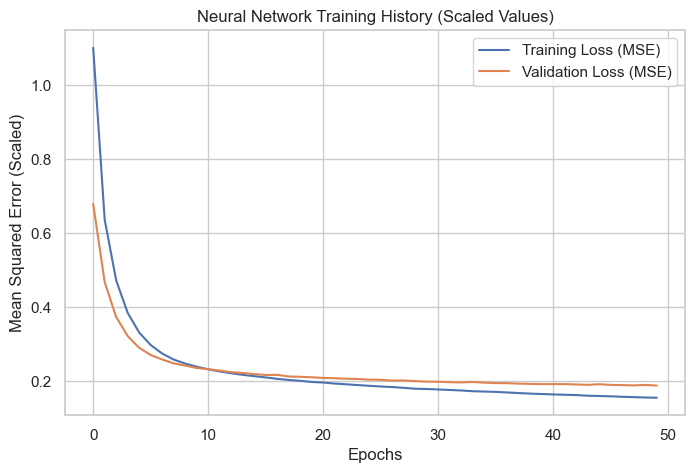

In [52]:
# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Neural Network Training History (Scaled Values)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Scaled)')
plt.legend()
plt.show()


In [53]:
# ==========================================
# 2.4.5 Evaluation
# ==========================================
# Predict on the test set (unseen data) -> Output will be in scaled format
y_pred_scaled = model.predict(X_test_scaled)

# Inverse transform predictions to get real revenue values back
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Calculate Evaluation Metrics using the ORIGINAL y_test and REVERTED y_pred
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("Neural Network Evaluation on Test Set (Original Scale):")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Coefficient of Determination (R2 Score): {r2:.4f}")
print("=" * 50)

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step
Neural Network Evaluation on Test Set (Original Scale):
Mean Squared Error (MSE): 812,905,104,670,720.00
Coefficient of Determination (R2 Score): 0.8285
